In [5]:
# ========================================
# 📌 1. IMPORTS & SETUP
# ========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
from gensim import corpora, models
from collections import Counter
from datetime import datetime

from sklearn.feature_extraction.text import CountVectorizer

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# %matplotlib inline
sns.set(style="whitegrid")

# ========================================
# 📌 2. LOAD DATA
# ========================================
file_path = r'C:\Users\ayedr\week-1\notebooks\raw_analyst_ratings.xlsx'
df = pd.read_excel(file_path)
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
df['date'] = pd.to_datetime(df['date'], utc=True)
news_df = df.copy()

# Clean and tokenize
news_df['tokens'] = news_df['headline'].astype(str).str.lower().str.split()
news_df['tokens'] = news_df['tokens'].apply(
    lambda x: [w for w in x if w not in stop_words and len(w) > 2]
)

# Create dictionary and corpus for LDA
dictionary = corpora.Dictionary(news_df['tokens'])
corpus = [dictionary.doc2bow(text) for text in news_df['tokens']]

# LDA model (adjust num_topics if needed)
lda_model = models.LdaModel(corpus, num_topics=5, id2word=dictionary, passes=15)

# Print discovered topics
for idx, topic in lda_model.print_topics():
    print(f"🔹 Topic {idx+1}:\n{topic}\n")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ayedr\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


🔹 Topic 1:
0.021*"announces" + 0.021*"new" + 0.013*"stocks" + 0.011*"shares" + 0.010*"update:" + 0.010*"therapeutics" + 0.008*"industry" + 0.008*"services" + 0.008*"set" + 0.007*"ceo"

🔹 Topic 2:
0.029*"downgrades" + 0.025*"price" + 0.025*"benzinga's" + 0.024*"maintains" + 0.024*"target" + 0.023*"raises" + 0.021*"buy" + 0.019*"upgrades" + 0.019*"top" + 0.017*"initiates"

🔹 Topic 3:
0.067*"eps" + 0.055*"reports" + 0.036*"sales" + 0.026*"est" + 0.020*"est." + 0.019*"sees" + 0.014*"revenue" + 0.014*"adj." + 0.013*"est;" + 0.011*"vs."

🔹 Topic 4:
0.028*"shares" + 0.018*"market" + 0.018*"trading" + 0.013*"update:" + 0.012*"qualcomm" + 0.012*"higher" + 0.011*"stocks" + 0.010*"52-week" + 0.010*"companies" + 0.010*"oil"

🔹 Topic 5:
0.055*"stocks" + 0.036*"earnings" + 0.027*"session" + 0.026*"moving" + 0.021*"scheduled" + 0.018*"pre-market" + 0.017*"mid-day" + 0.017*"watch" + 0.014*"top" + 0.011*"2018"



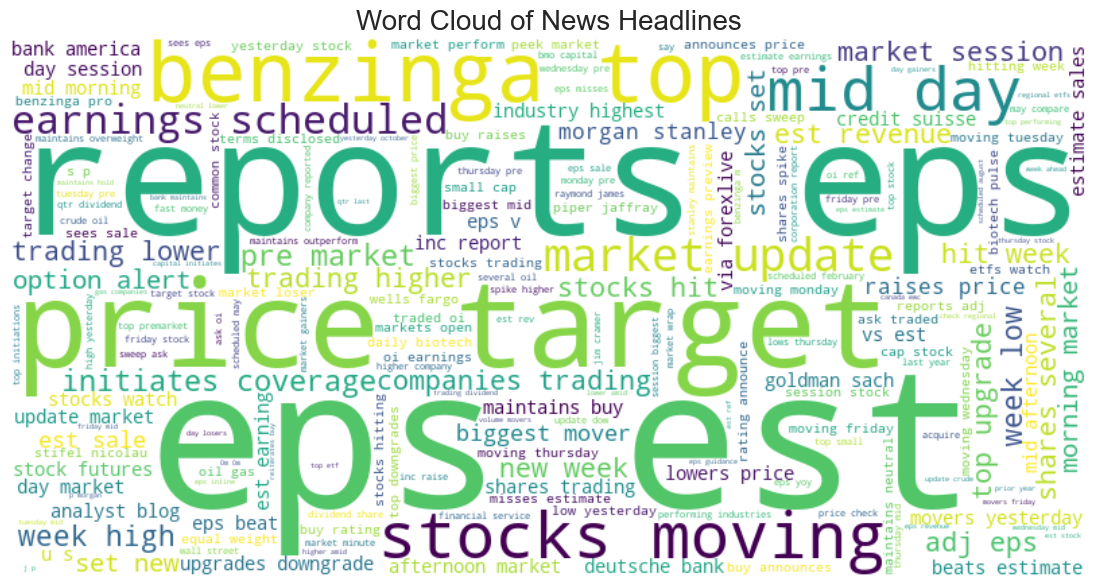

In [6]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Join tokens for WordCloud
all_words = ' '.join([' '.join(tokens) for tokens in news_df['tokens']])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

# Plot
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of News Headlines", fontsize=20)
plt.show()
